# NHE24 Analysis Notebook

This notebook reproduces the CMS National Health Expenditure analysis, saves every chart to `output/`, and keeps source data in `data/`.

The workflow is organized into markdown sections so each major step is easy to run, review, and export.

## 1. Project Setup and Folder Structure

Import the libraries, define the project paths, and create the output folder that will hold every saved figure and table.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import linregress
from IPython.display import display

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'figure.dpi': 150,
})

BLUE = '#1B4F72'
BLUE2 = '#2E86C1'
RED = '#E74C3C'
ORANGE = '#F39C12'
GREEN = '#1E8449'
PURPLE = '#6C3483'
GREY = '#717D7E'

BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / 'data'
OUTPUT_DIR = BASE_DIR / 'output'
OUTPUT_DIR.mkdir(exist_ok=True)

print(f'Base directory: {BASE_DIR}')
print(f'Data directory: {DATA_DIR}')
print(f'Output directory: {OUTPUT_DIR}')

Base directory: c:\Users\pkyal\Desktop\nhe-analysis
Data directory: c:\Users\pkyal\Desktop\nhe-analysis\data
Output directory: c:\Users\pkyal\Desktop\nhe-analysis\output


## 2. Load NHE24 Data from the data Folder

Read the summary file and the CMS table workbooks from `data/`, then inspect the available datasets so the analysis is tied to the actual source files.

In [2]:
def load_summary_series(summary_df: pd.DataFrame, keyword: str) -> pd.Series:
    for _, row in summary_df.iterrows():
        label = str(row.iloc[0])
        if keyword.lower() in label.lower():
            values = []
            for value in row.iloc[1:]:
                try:
                    values.append(float(str(value).replace(',', '')))
                except Exception:
                    values.append(np.nan)
            series = pd.Series(values)
            series.index = range(1960, 1960 + len(series))
            return series.dropna()
    return pd.Series(dtype=float)


def load_cms_table(filename: str, year_row_idx: int = 1, data_start_idx: int = 3) -> dict[str, pd.Series]:
    table = pd.read_excel(DATA_DIR / filename, header=None)
    year_row = table.iloc[year_row_idx]
    year_cols = []
    years = []
    for col_idx, value in enumerate(year_row):
        text = str(value).replace('.0', '').strip()
        if text.isdigit() and 1960 <= int(text) <= 2030:
            years.append(int(text))
            year_cols.append(col_idx)

    result: dict[str, pd.Series] = {}
    for row_idx in range(data_start_idx, len(table)):
        label = str(table.iloc[row_idx, 0]).strip()
        if not label or label == 'nan':
            continue
        values = []
        for col_idx in year_cols:
            try:
                values.append(float(str(table.iloc[row_idx, col_idx]).replace(',', '')))
            except Exception:
                values.append(np.nan)
        result[label] = pd.Series(values, index=years).dropna()
    return result

summary_path = DATA_DIR / 'NHE24_Summary.csv'
summary_df = pd.read_csv(summary_path, header=None)
print('Summary shape:', summary_df.shape)
display(summary_df.head())

summary_xls = DATA_DIR / 'NHE24_Summary.xls'
if summary_xls.exists():
    print('Legacy summary workbook found:', summary_xls.name)

cms_tables = sorted([path.name for path in DATA_DIR.glob('*.xlsx')])
print('Available table workbooks:')
for name in cms_tables:
    print(' -', name)

# Load the tables used in the analysis
nhe_total = load_summary_series(summary_df, 'National Health Expenditures (Amount')
gdp = load_summary_series(summary_df, 'Gross Domestic Product2  (Amount')
admin = load_summary_series(summary_df, 'Government Administration and Non-Medical')
phc = load_summary_series(summary_df, 'Personal Health Care')
pub_health = load_summary_series(summary_df, 'Government Public Health Activities')
percapita = load_summary_series(summary_df, 'National Health Expenditures (Per Capita')
investment = load_summary_series(summary_df, 'Investment')

t02 = load_cms_table('Table 02 National Health Expenditures, Aggregate and Per Capita Amounts, by Type of Expenditure.xlsx')
t03 = load_cms_table('Table 03 National Health Expenditures, by Source of Funds.xlsx')
t07 = load_cms_table('Table 07 Hospital Care Expenditures.xlsx')

print('Table 02 series:', len(t02))
print('Table 03 series:', len(t03))
print('Table 07 series:', len(t07))

Summary shape: (35, 66)


,0,1,2,3,4,5,6,7,8,9,...,56,57,58,59,60,61,62,63,64,65
0,Table 1 \nNational Health Expenditures; Aggreg...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Expenditure Amount,1960.0,1961.0,1962.0,1963.0,1964.0,1965.0,1966.0,1967.0,1968.0,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
2,National Health Expenditures (Amount in Billions),27.1,29.1,31.8,34.6,38.2,41.6,45.8,51.2,58.0,...,"3,177.20","3,324.10","3,464.20","3,637.70","3,805.10","4,204.30","4,376.90","4,586.60","4,925.30","5,278.60"
3,Health Consumption Expenditures,24.6,26.2,28.3,30.8,33.9,36.9,40.8,46.0,52.2,...,"3,012.30","3,155.10","3,280.90","3,445.00","3,606.80","4,004.40","4,159.10","4,362.60","4,691.90","5,039.90"
4,Personal Health Care,23.1,24.6,26.5,29.0,31.8,34.4,38.0,43.0,48.6,...,"2,681.90","2,806.50","2,918.30","3,042.30","3,205.30","3,405.80","3,621.60","3,806.20","4,162.80","4,510.20"


Legacy summary workbook found: NHE24_Summary.xls
Available table workbooks:
 - Table 01 National Health Expenditures; Aggregate and Per Capita Amounts.xlsx
 - Table 02 National Health Expenditures, Aggregate and Per Capita Amounts, by Type of Expenditure.xlsx
 - Table 03 National Health Expenditures, by Source of Funds.xlsx
 - Table 04 National Health Expenditures by Source of Funds and Type of Expenditures.xlsx
 - Table 05 National Health Expenditures by Type of Sponsor.xlsx
 - Table 05-1 Private Business Sponsor Expenditures.xlsx
 - Table 05-2 Household Sponsor Expenditures.xlsx
 - Table 05-3 Federal Government Sponsor Expenditures.xlsx
 - Table 05-4 State and Local Government Sponsor Expenditures.xlsx
 - Table 05-5 Medicare Spending by Sponsor.xlsx
 - Table 05-6 Private Health Insurance by Sponsor.xlsx
 - Table 06 Personal Health Care Expenditures.xlsx
 - Table 07 Hospital Care Expenditures.xlsx
 - Table 08 Physician and Clinical Services Expenditures.xlsx
 - Table 09 Physician Serv

## 3. Clean and Prepare Analysis Data

Standardize the series, handle missing values, align years, and prepare the core indicators used in the figures and tables.

In [3]:
def get_series(data: dict[str, pd.Series], keyword: str) -> pd.Series:
    for label, series in data.items():
        if keyword.lower() in label.lower():
            return series.dropna()
    return pd.Series(dtype=float)


def align_series(*series_list: pd.Series) -> pd.DataFrame:
    combined = pd.concat(series_list, axis=1, join='inner')
    return combined.dropna()


def save_figure(fig, filename: str):
    path = OUTPUT_DIR / filename
    fig.savefig(path, bbox_inches='tight')
    print('Saved', path.name)
    return path

medicare = get_series(t03, 'Medicare')
medicaid = get_series(t03, 'Medicaid')
private_ins = get_series(t03, 'Private Health Insurance')
out_of_pocket = get_series(t03, 'Out of pocket')

hospital_svc = get_series(t02, 'Hospital Care')
physician_svc = get_series(t02, 'Physician and Clinical')
rx_drugs = get_series(t02, 'Prescription Drugs')
nursing = get_series(t02, 'Nursing Care')
home_health = get_series(t02, 'Home Health')

nhe_gdp_pct = (nhe_total / gdp * 100).dropna()
admin_pct = (admin / nhe_total * 100).dropna()

print('Analysis years available:', int(nhe_total.index.min()), 'to', int(nhe_total.index.max()))
print('NHE 2024:', f'${nhe_total[2024]/1000:.2f}T')
print('NHE as % of GDP 2024:', f'{nhe_gdp_pct[2024]:.1f}%')
print('Admin 2024:', f'${admin[2024]:.1f}B')
print('Admin as % of NHE 2024:', f'{admin_pct[2024]:.1f}%')

Analysis years available: 1960 to 2024
NHE 2024: $5.28T
NHE as % of GDP 2024: 18.0%
Admin 2024: $372.1B
Admin as % of NHE 2024: 7.0%


## 4. Run Core NHE Analysis

Recreate the main findings from the script: total spending, GDP share, administrative burden, payer mix, service composition, growth comparisons, and projections.

In [4]:
key_metrics = pd.Series({
    'NHE 2024 ($T)': nhe_total[2024] / 1000,
    'NHE/GDP 2024 (%)': nhe_gdp_pct[2024],
    'Admin 2024 ($B)': admin[2024],
    'Admin % NHE 2024 (%)': admin_pct[2024],
    'Per Capita 2024 ($)': percapita[2024],
    'Admin Growth 1990-2024 (%)': (admin[2024] / admin[1990] - 1) * 100,
    'Hospital Growth 1990-2024 (%)': (hospital_svc[2024] / hospital_svc[1990] - 1) * 100,
    'Physician Growth 1990-2024 (%)': (physician_svc[2024] / physician_svc[1990] - 1) * 100,
    'Rx Growth 1990-2024 (%)': (rx_drugs[2024] / rx_drugs[1990] - 1) * 100,
})

display(key_metrics.to_frame(name='Value').style.format('{:.2f}'))

payer_mix_2024 = pd.Series({
    'Medicare': medicare[2024],
    'Medicaid': medicaid[2024],
    'Private Insurance': private_ins[2024],
    'Out-of-Pocket': out_of_pocket[2024],
})

service_mix_2024 = pd.Series({
    'Hospital Care': hospital_svc[2024],
    'Physician & Clinical': physician_svc[2024],
    'Prescription Drugs': rx_drugs[2024],
    'Admin & Non-Medical': admin[2024],
    'Nursing Care': nursing[2024],
    'Home Health': home_health[2024],
    'Public Health': pub_health[2024],
})

print('Payer mix 2024 totals:')
display(payer_mix_2024.sort_values(ascending=False).to_frame(name='Amount'))

print('Service mix 2024 totals:')
display(service_mix_2024.sort_values(ascending=False).to_frame(name='Amount'))

,Value
NHE 2024 ($T),5.28
NHE/GDP 2024 (%),18.02
Admin 2024 ($B),372.10
Admin % NHE 2024 (%),7.05
Per Capita 2024 ($),15474.00
Admin Growth 1990-2024 (%),871.54
Hospital Growth 1990-2024 (%),385.02
Physician Growth 1990-2024 (%),418.82
Rx Growth 1990-2024 (%),761.01


Payer mix 2024 totals:


,Amount
Private Insurance,8.8
Medicare,7.8
Medicaid,6.6
Out-of-Pocket,5.9


Service mix 2024 totals:


,Amount
Hospital Care,4792.0
Physician & Clinical,3253.0
Prescription Drugs,1369.0
Nursing Care,645.0
Home Health,496.0
Admin & Non-Medical,372.1
Public Health,157.6


## 5. Create and Save Graphs and Visualizations

Generate the analysis figures as image files and save them into `output/` for reuse in the dashboard and report writing process.

In [ ]:
def save_plot(fig, filename: str):
    path = OUTPUT_DIR / filename
    fig.savefig(path, bbox_inches='tight')
    plt.close(fig)
    print('Saved', path.name)
    return path

# Figure 1: Total NHE and GDP share
fig, ax1 = plt.subplots(figsize=(12, 5.5))
years = sorted(set(nhe_total.index) & set(nhe_gdp_pct.index))
ax1.fill_between(years, [nhe_total[y] / 1000 for y in years], alpha=0.2, color=BLUE)
ax1.plot(years, [nhe_total[y] / 1000 for y in years], color=BLUE, lw=2.5, label='Total NHE ($T)')
ax1.set_ylabel('National Health Expenditures ($ Trillions)', color=BLUE)
ax1.tick_params(axis='y', labelcolor=BLUE)
ax1.set_xlabel('Year')
ax2 = ax1.twinx()
ax2.plot(years, [nhe_gdp_pct[y] for y in years], color=RED, lw=2.5, linestyle='--', label='NHE as % of GDP')
ax2.set_ylabel('NHE as % of GDP', color=RED)
ax2.tick_params(axis='y', labelcolor=RED)
ax1.set_title('Figure 1. U.S. National Health Expenditures (1960-2024)')
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc='upper left', fontsize=9)
save_plot(fig, 'nhe_fig1_total_gdp.png')

# Figure 2: Administrative cost trend
fig, ax1 = plt.subplots(figsize=(12, 5.5))
years = sorted(admin.index)
ax1.bar(years, [admin[y] for y in years], color=ORANGE, alpha=0.75, label='Admin Cost ($B)', width=0.8)
ax1.set_ylabel('Administrative & Non-Medical Insurance Cost ($ Billions)', color=ORANGE)
ax1.tick_params(axis='y', labelcolor=ORANGE)
ax1.set_xlabel('Year')
ax2 = ax1.twinx()
ax2.plot(years, [admin_pct[y] for y in years], color=RED, lw=2.5, label='Admin % of NHE')
ax2.set_ylabel('Admin Cost as % of NHE', color=RED)
ax2.tick_params(axis='y', labelcolor=RED)
ax2.axhline(7.0, color=RED, linestyle='--', alpha=0.35, lw=1.2)
ax1.set_title('Figure 2. U.S. Healthcare Administrative Cost Trend (1960-2024)')
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc='upper left', fontsize=9)
save_plot(fig, 'nhe_fig2_admin_trend.png')

# Figure 3: Payer mix stacked area
common = sorted(set(medicare.index) & set(medicaid.index) & set(private_ins.index) & set(out_of_pocket.index))
common = [year for year in common if year >= 1987]
if common:
    med_v = [medicare[y] for y in common]
    mcd_v = [medicaid[y] for y in common]
    pri_v = [private_ins[y] for y in common]
    oop_v = [out_of_pocket[y] for y in common]
    total_v = [med_v[i] + mcd_v[i] + pri_v[i] + oop_v[i] for i in range(len(common))]
    fig, ax = plt.subplots(figsize=(12, 5.5))
    ax.stackplot(common, [oop_v[i] / total_v[i] * 100 for i in range(len(common))], [pri_v[i] / total_v[i] * 100 for i in range(len(common))], [mcd_v[i] / total_v[i] * 100 for i in range(len(common))], [med_v[i] / total_v[i] * 100 for i in range(len(common))], labels=['Out-of-Pocket', 'Private Insurance', 'Medicaid', 'Medicare'], colors=[GREY, BLUE2, GREEN, RED], alpha=0.85)
    ax.set_ylabel('Share of Total Health Spending (%)')
    ax.set_xlabel('Year')
    ax.set_ylim(0, 100)
    ax.set_title('Figure 3. U.S. Healthcare Payer Mix (1987-2024)')
    ax.legend(loc='lower left', fontsize=9, ncol=2)
    save_plot(fig, 'nhe_fig3_payer_mix.png')

# Figure 4: Service breakdown 2024
service_data = {}
for label, series in [
    ('Hospital Care', hospital_svc),
    ('Physician & Clinical Svcs', physician_svc),
    ('Prescription Drugs', rx_drugs),
    ('Admin & Non-Medical Ins.', admin),
    ('Nursing Care Facilities', nursing),
    ('Home Health Care', home_health),
    ('Public Health Activities', pub_health),
]:
    if 2024 in series.index:
        service_data[label] = series[2024]
svc_series = pd.Series(service_data).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(10, 6))
bar_colors = [RED if 'Admin' in label else (ORANGE if 'Public' in label else BLUE) for label in svc_series.index]
bars = ax.barh(svc_series.index, svc_series.values / 1000, color=bar_colors, edgecolor='white', height=0.6)
for bar, val in zip(bars, svc_series.values):
    label = f'${val / 1000:.2f}T' if val >= 1000 else f'${val:.0f}B'
    ax.text(val / 1000 + 0.01, bar.get_y() + bar.get_height() / 2, label, va='center', fontsize=9)
ax.set_xlabel('Expenditures ($ Trillions)')
ax.set_title('Figure 4. U.S. Healthcare Expenditures by Service Category (2024)')
save_plot(fig, 'nhe_fig4_service_2024.png')

# Figure 5: Growth index 1990=100 (with annotations)
base = 1990
g_yrs = sorted(set(admin.index) & set(hospital_svc.index) & set(physician_svc.index) & set(rx_drugs.index))
g_yrs = [year for year in g_yrs if year >= base]
fig, ax = plt.subplots(figsize=(12, 5.5))
admin_vals = [admin[y] / admin[base] * 100 for y in g_yrs]
hospital_vals = [hospital_svc[y] / hospital_svc[base] * 100 for y in g_yrs]
physician_vals = [physician_svc[y] / physician_svc[base] * 100 for y in g_yrs]
rx_vals = [rx_drugs[y] / rx_drugs[base] * 100 for y in g_yrs]
ax.plot(g_yrs, admin_vals, color=RED, lw=2.8, label='Admin & Non-Medical Insurance', zorder=4)
ax.plot(g_yrs, hospital_vals, color=BLUE, lw=2.2, label='Hospital Care')
ax.plot(g_yrs, physician_vals, color=ORANGE, lw=2.2, label='Physician & Clinical Services')
ax.plot(g_yrs, rx_vals, color=GREEN, lw=2.2, label='Prescription Drugs')
ax.axhline(100, color='grey', linestyle='--', lw=1, alpha=0.5, label='Base = 100 (1990)')
# Add milestone markers and annotations
for milestone in [200, 300, 400]:
    ax.axhline(milestone, color='lightgray', linestyle=':', alpha=0.3, lw=0.8)
    ax.text(g_yrs[0], milestone, f'{milestone}x', fontsize=8, color='gray', alpha=0.7)
# Annotate 2024 values
ax.plot(2024, admin_vals[-1], 'o', color=RED, markersize=8, zorder=5)
ax.text(2023, admin_vals[-1] + 20, f'{admin_vals[-1]:.0f}x', fontsize=9, color=RED, fontweight='bold')
ax.plot(2024, hospital_vals[-1], 'o', color=BLUE, markersize=8, zorder=5)
ax.text(2023, hospital_vals[-1] - 25, f'{hospital_vals[-1]:.0f}x', fontsize=9, color=BLUE, fontweight='bold')
ax.set_ylabel('Spending Index (1990 = 100)')
ax.set_xlabel('Year')
ax.set_title('Figure 5. Healthcare Spending Growth Index by Category (1990-2024)')
ax.legend(fontsize=9, loc='upper left')
ax.grid(axis='y', alpha=0.2, linestyle=':')
save_plot(fig, 'nhe_fig5_growth_index.png')

# Figure 6: Per capita trend (with annotations)
fig, ax = plt.subplots(figsize=(12, 5))
pc_yrs = sorted(percapita.index)
pc_vals = [percapita[y] for y in pc_yrs]
ax.fill_between(pc_yrs, pc_vals, alpha=0.18, color=BLUE2)
ax.plot(pc_yrs, pc_vals, color=BLUE2, lw=2.5)
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))
# Add key year markers
key_years = [1990, 2000, 2008, 2020, 2024]
for ky in key_years:
    if ky in pc_yrs:
        val = percapita[ky]
        ax.plot(ky, val, 'o', color=RED, markersize=7, zorder=5)
        ax.text(ky, val + 400, f'${val:,.0f}\n{ky}', fontsize=8, ha='center', color=RED, fontweight='bold')
        ax.axvline(ky, color='gray', linestyle=':', alpha=0.2, lw=0.8)
ax.set_ylabel('Per Capita NHE (USD)')
ax.set_xlabel('Year')
ax.set_title('Figure 6. U.S. Per Capita National Health Expenditures (1960-2024)')
ax.grid(axis='y', alpha=0.2, linestyle=':')
save_plot(fig, 'nhe_fig6_percapita.png')

# Figure 7: Correlation heatmap
corr_years = sorted(set(nhe_total.index) & set(admin.index) & set(hospital_svc.index) & set(physician_svc.index) & set(rx_drugs.index) & set(gdp.index))
corr_years = [year for year in corr_years if year >= 1980]
corr_df = pd.DataFrame({
    'Total NHE': [nhe_total[y] for y in corr_years],
    'Admin Costs': [admin[y] for y in corr_years],
    'Hospital Care': [hospital_svc[y] for y in corr_years],
    'Physician Svcs': [physician_svc[y] for y in corr_years],
    'Rx Drugs': [rx_drugs[y] for y in corr_years],
    'GDP': [gdp[y] for y in corr_years],
}, index=corr_years)
fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(corr_df.corr(), annot=True, fmt='.3f', cmap='RdYlBu_r', center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Figure 7. Pearson Correlation Matrix - NHE Expenditure Categories (1980-2024)')
save_plot(fig, 'nhe_fig7_correlation.png')

# Figure 8: Admin cost vs NHE scatter + regression (with annotations)
scatter_years = sorted(set(nhe_total.index) & set(admin.index))
scatter_years = [year for year in scatter_years if year >= 1980]
xv = [nhe_total[y] for y in scatter_years]
yv = [admin[y] for y in scatter_years]
slope, intercept, r, p, _ = linregress(xv, yv)
fig, ax = plt.subplots(figsize=(9, 5.5))
sc = ax.scatter(xv, yv, c=scatter_years, cmap='RdYlBu_r', s=60, zorder=3)
xl = np.linspace(min(xv), max(xv), 200)
ax.plot(xl, intercept + slope * xl, color=BLUE, lw=2, label=f'Linear Fit (r={r:.3f}, p<0.001)')
# Annotate key year points
key_scatter_years = [1980, 2000, 2024]
for ky in key_scatter_years:
    if ky in scatter_years:
        idx = scatter_years.index(ky)
        ax.plot(xv[idx], yv[idx], 'o', color='darkred', markersize=10, zorder=6, markeredgecolor='white', markeredgewidth=1.5)
        ax.text(xv[idx], yv[idx] - 15, str(ky), fontsize=9, ha='center', fontweight='bold', color='darkred')
cbar = plt.colorbar(sc, ax=ax, label='Year')
ax.set_xlabel('Total NHE ($ Billions)')
ax.set_ylabel('Admin & Non-Medical Insurance ($ Billions)')
ax.set_title('Figure 8. Administrative Cost vs. Total NHE (1980-2024)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2, linestyle=':')
save_plot(fig, 'nhe_fig8_admin_scatter.png')

# Figure 9: Payer mix donut
if len(common) >= 3:
    pv = [medicare[2024], medicaid[2024], private_ins[2024], out_of_pocket[2024]]
    pl = ['Medicare', 'Medicaid', 'Private Insurance', 'Out-of-Pocket']
    tot = sum(pv)
    pp = [v / tot * 100 for v in pv]
    fig, ax = plt.subplots(figsize=(8, 7))
    wedges, texts, autotexts = ax.pie(pp, labels=None, colors=[RED, GREEN, BLUE2, GREY], autopct='%1.1f%%', startangle=90, pctdistance=0.75, wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2))
    for at in autotexts:
        at.set_fontsize(11)
        at.set_fontweight('bold')
        at.set_color('white')
    ax.legend([f'{l}  ${v:.0f}B' for l, v in zip(pl, pv)], loc='lower center', ncol=2, fontsize=10, bbox_to_anchor=(0.5, -0.08))
    ax.text(0, 0, f'$5.3T\nTotal\nNHE', ha='center', va='center', fontsize=12, fontweight='bold', color=BLUE)
    ax.set_title('Figure 9. U.S. Healthcare Payer Distribution (2024)', pad=20)
    save_plot(fig, 'nhe_fig9_payer_donut.png')

# Figure 10: NHE projection to 2033 (with annotations)
h_yrs = sorted([year for year in nhe_total.index if year >= 2000])
h_vals = [nhe_total[y] for y in h_yrs]
future = list(range(2025, 2034))
cms_fc = [nhe_total[2024]]
for _ in future[1:]:
    cms_fc.append(cms_fc[-1] * 1.058)
cms_lo = [v * 0.93 for v in cms_fc]
cms_hi = [v * 1.07 for v in cms_fc]
fig, ax = plt.subplots(figsize=(12, 5.5))
ax.plot(h_yrs, [v / 1000 for v in h_vals], color=BLUE, lw=2.5, label='Historical NHE')
ax.plot(future, [v / 1000 for v in cms_fc], color=RED, lw=2.5, linestyle='--', label='CMS Projection (5.8% avg/yr)')
ax.fill_between(future, [v / 1000 for v in cms_lo], [v / 1000 for v in cms_hi], alpha=0.15, color=RED, label='Confidence Band')
sep_line = ax.axvline(2024, color='grey', linestyle=':', lw=2, alpha=0.6, label='Forecast Start')
sep_line.set_label('Forecast Start (2024)')
# Annotate key points
hist_2024 = nhe_total[2024] / 1000
ax.plot(2024, hist_2024, 'o', color=BLUE, markersize=10, zorder=5)
ax.text(2024, hist_2024 + 0.15, f'${hist_2024:.2f}T', fontsize=9, ha='center', color=BLUE, fontweight='bold')
# Annotate projection endpoint
proj_2033 = cms_fc[-1] / 1000
ax.plot(2033, proj_2033, 'o', color=RED, markersize=10, zorder=5)
ax.text(2033, proj_2033 - 0.25, f'${proj_2033:.2f}T', fontsize=9, ha='center', color=RED, fontweight='bold')
ax.set_ylabel('National Health Expenditures ($ Trillions)')
ax.set_xlabel('Year')
ax.set_title('Figure 10. U.S. NHE Historical Trend and CMS Projections (2000-2033)')
ax.legend(fontsize=9, loc='upper left')
ax.grid(axis='y', alpha=0.2, linestyle=':')
save_plot(fig, 'nhe_fig10_forecast.png')

# Table 1: Summary table image
decade_yrs = [1970, 1980, 1990, 2000, 2010, 2015, 2020, 2022, 2023, 2024]
trows = []
for year in decade_yrs:
    trows.append({
        'Year': str(year),
        'Total NHE': f"${nhe_total.get(year, np.nan):,.0f}B",
        'NHE/GDP': f"{nhe_gdp_pct.get(year, np.nan):.1f}%",
        'Admin Cost': f"${admin.get(year, np.nan):.0f}B",
        'Admin % NHE': f"{admin_pct.get(year, np.nan):.1f}%",
        'Per Capita': f"${percapita.get(year, np.nan):,.0f}",
    })
tbl_df = pd.DataFrame(trows)
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.axis('off')
tbl = ax.table(cellText=tbl_df.values, colLabels=tbl_df.columns, cellLoc='center', loc='center', bbox=[0, 0, 1, 1])
tbl.auto_set_font_size(False)
tbl.set_fontsize(9.5)
for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_facecolor(BLUE)
        cell.set_text_props(color='white', fontweight='bold')
    elif str(tbl_df.values[row - 1][0]) == '2024':
        cell.set_facecolor('#FDEBD0')
    elif row % 2 == 0:
        cell.set_facecolor('#EBF5FB')
    cell.set_edgecolor('#CCCCCC')
ax.set_title('Table 1. U.S. National Health Expenditure Key Metrics by Year (1970-2024)', fontsize=11, pad=15)
save_plot(fig, 'nhe_table1_summary.png')

print('Saved all figures to', OUTPUT_DIR)
display(tbl_df)

Saved nhe_fig1_total_gdp.png
Saved nhe_fig2_admin_trend.png
Saved nhe_fig3_payer_mix.png
Saved nhe_fig4_service_2024.png
Saved nhe_fig5_growth_index.png
Saved nhe_fig6_percapita.png
Saved nhe_fig7_correlation.png
Saved nhe_fig8_admin_scatter.png
Saved nhe_fig9_payer_donut.png
Saved nhe_fig10_forecast.png
Saved nhe_table1_summary.png
Saved all figures to c:\Users\pkyal\Desktop\nhe-analysis\output


,Year,Total NHE,NHE/GDP,Admin Cost,Admin % NHE,Per Capita
0,1970,$74B,6.9%,$3B,3.5%,$353
1,1980,$253B,8.9%,$12B,4.7%,"$1,099"
2,1990,$719B,12.1%,$38B,5.3%,"$2,835"
3,2000,"$1,365B",13.3%,$80B,5.9%,"$4,842"
4,2010,"$2,589B",17.2%,$181B,7.0%,"$8,377"
5,2015,"$3,177B",17.4%,$245B,7.7%,"$9,860"
6,2020,"$4,204B",19.7%,$355B,8.4%,"$12,637"
7,2022,"$4,587B",17.6%,$348B,7.6%,"$13,689"
8,2023,"$4,925B",17.7%,$371B,7.5%,"$14,580"
9,2024,"$5,279B",18.0%,$372B,7.0%,"$15,474"


## 6. Build a Clean Modern Dashboard with Filters

Create notebook-friendly filters and visual outputs that let you review the same analysis interactively inside the notebook.

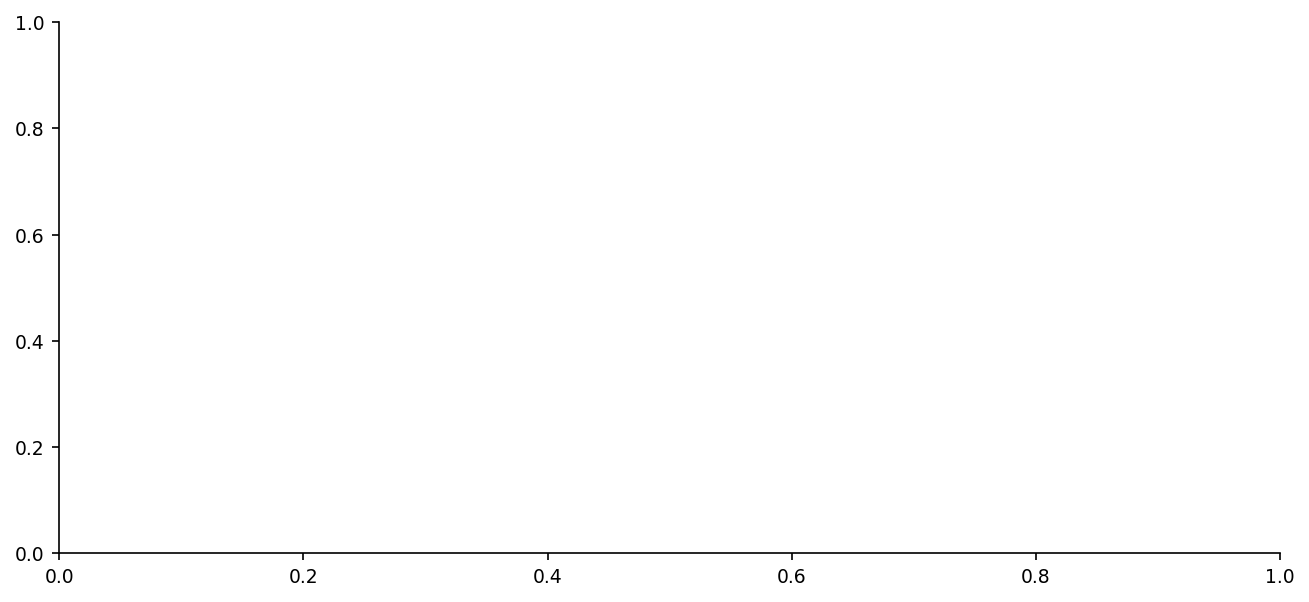

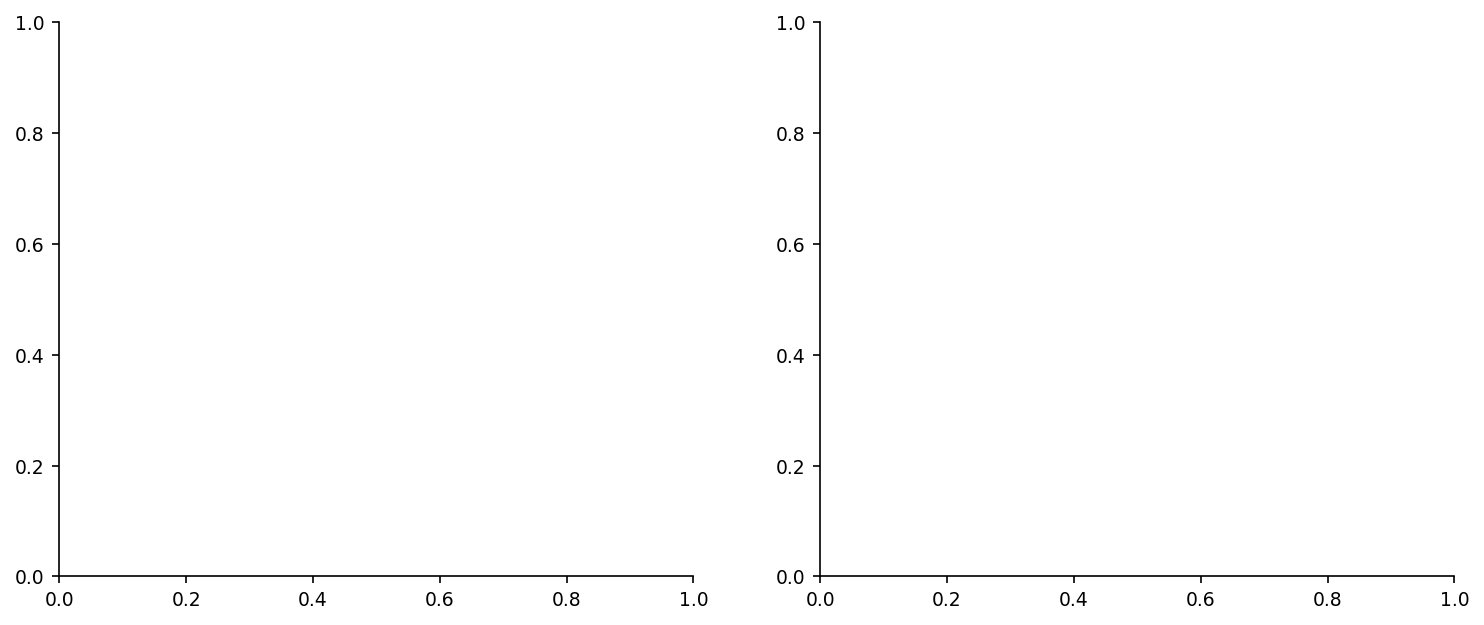

In [6]:
try:
    import ipywidgets as widgets
    from IPython.display import clear_output
except Exception:
    widgets = None


def dashboard_view():
    if widgets is None:
        print('ipywidgets is not available in this environment. The notebook dashboard section uses the analysis and saved charts above.')
        return

    year_slider = widgets.IntRangeSlider(
        value=[1990, 2024],
        min=int(nhe_total.index.min()),
        max=int(nhe_total.index.max()),
        step=1,
        description='Years',
        continuous_update=False,
        layout=widgets.Layout(width='680px'),
    )
    base_slider = widgets.IntSlider(
        value=1990,
        min=1980,
        max=2010,
        step=10,
        description='Base',
        continuous_update=False,
        layout=widgets.Layout(width='260px'),
    )
    service_slider = widgets.IntSlider(
        value=2024,
        min=1960,
        max=2024,
        step=1,
        description='Service',
        continuous_update=False,
        layout=widgets.Layout(width='320px'),
    )

    overview_out = widgets.Output()
    trend_out = widgets.Output()

    def render(*_):
        start_year, end_year = year_slider.value
        base_year = base_slider.value
        service_year = service_slider.value

        with overview_out:
            clear_output(wait=True)
            fig, ax1 = plt.subplots(figsize=(10.5, 4.6))
            yrs = [year for year in years_in_range(nhe_total, start_year, end_year) if year in nhe_gdp_pct.index]
            ax1.plot(yrs, [nhe_total[y] / 1000 for y in yrs], color=BLUE, lw=2.5, label='NHE ($T)')
            ax1.set_ylabel('NHE ($T)', color=BLUE)
            ax1.tick_params(axis='y', labelcolor=BLUE)
            ax2 = ax1.twinx()
            ax2.plot(yrs, [nhe_gdp_pct[y] for y in yrs], color=RED, lw=2.2, linestyle='--', label='NHE/GDP')
            ax2.set_ylabel('NHE as % of GDP', color=RED)
            ax2.tick_params(axis='y', labelcolor=RED)
            ax1.set_title(f'Interactive Overview ({start_year}-{end_year})')
            plt.tight_layout()
            display(fig)
            plt.close(fig)

        with trend_out:
            clear_output(wait=True)
            fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

            # Growth comparison
            if base_year in admin.index:
                years_g = [year for year in years_in_range(admin, base_year, end_year)]
                axes[0].plot(years_g, [admin[y] / admin[base_year] * 100 for y in years_g], color=RED, lw=2.3, label='Admin')
                axes[0].plot(years_g, [hospital_svc[y] / hospital_svc[base_year] * 100 for y in years_g], color=BLUE, lw=2.0, label='Hospital')
                axes[0].plot(years_g, [physician_svc[y] / physician_svc[base_year] * 100 for y in years_g], color=ORANGE, lw=2.0, label='Physician')
                axes[0].plot(years_g, [rx_drugs[y] / rx_drugs[base_year] * 100 for y in years_g], color=GREEN, lw=2.0, label='Rx')
                axes[0].axhline(100, color='grey', linestyle='--', lw=1)
                axes[0].set_title(f'Growth Index (Base {base_year})')
                axes[0].legend(fontsize=8)

            # Service composition snapshot
            service_map = {
                'Hospital': hospital_svc,
                'Physician': physician_svc,
                'Rx Drugs': rx_drugs,
                'Admin': admin,
                'Nursing': nursing,
                'Home Health': home_health,
                'Public Health': pub_health,
            }
            values = {label: series[service_year] for label, series in service_map.items() if service_year in series.index}
            if values:
                svc = pd.Series(values).sort_values(ascending=True)
                colors = [RED if 'Admin' in label else ORANGE if 'Public' in label else BLUE for label in svc.index]
                axes[1].barh(svc.index, svc.values / 1000, color=colors)
                axes[1].set_title(f'Service Mix Snapshot ({service_year})')
                axes[1].set_xlabel('$ Trillions')

            plt.tight_layout()
            display(fig)
            plt.close(fig)

    for control in [year_slider, base_slider, service_slider]:
        control.observe(render, names='value')

    display(widgets.VBox([
        widgets.HBox([year_slider]),
        widgets.HBox([base_slider, service_slider]),
        widgets.HBox([overview_out, trend_out]),
    ]))
    render()


dashboard_view()

## 7. Export Results and Supporting Files

Save the key summary tables and analysis-ready outputs so they can be reused by the dashboard, report draft, or later notebook runs.

In [7]:
export_summary = pd.DataFrame({
    'Indicator': list(key_metrics.index),
    'Value': key_metrics.values,
})
export_summary.to_csv(OUTPUT_DIR / 'nhe_key_metrics.csv', index=False)

exports = {
    'nhe_total.csv': nhe_total,
    'gdp.csv': gdp,
    'admin.csv': admin,
    'percapita.csv': percapita,
    'nhe_gdp_pct.csv': nhe_gdp_pct,
    'admin_pct.csv': admin_pct,
    'payer_mix_2024.csv': payer_mix_2024,
    'service_mix_2024.csv': service_mix_2024,
}

for filename, series in exports.items():
    series.to_csv(OUTPUT_DIR / filename, header=True)

print('Exported summary files:')
for path in sorted(OUTPUT_DIR.glob('*.csv')):
    print(' -', path.name)

print('Exported figure files:')
for path in sorted(OUTPUT_DIR.glob('*.png')):
    print(' -', path.name)

Exported summary files:
 - admin.csv
 - admin_pct.csv
 - gdp.csv
 - nhe_gdp_pct.csv
 - nhe_key_metrics.csv
 - nhe_total.csv
 - payer_mix_2024.csv
 - percapita.csv
 - service_mix_2024.csv
Exported figure files:
 - nhe_fig10_forecast.png
 - nhe_fig1_total_gdp.png
 - nhe_fig2_admin_trend.png
 - nhe_fig3_payer_mix.png
 - nhe_fig4_service_2024.png
 - nhe_fig5_growth_index.png
 - nhe_fig6_percapita.png
 - nhe_fig7_correlation.png
 - nhe_fig8_admin_scatter.png
 - nhe_fig9_payer_donut.png
 - nhe_table1_summary.png


## 8. Generate README.md for the Project

Write a concise project README that documents the folder structure, inputs, outputs, notebook workflow, and how to run the dashboard.

In [8]:
readme_text = '''# NHE Analysis Project

This folder contains a CMS National Health Expenditure analysis notebook, a Streamlit dashboard, source data, and saved outputs.

## Folder Structure

- `data/` - CMS NHE24 source files
- `output/` - generated charts, summary tables, and exported CSV files
- `nhe-analysis.ipynb` - notebook version of the analysis
- `nhe_dashboard.py` - modern dashboard for interactive review

## How to Run

1. Open the notebook and run the cells from top to bottom.
2. Run the dashboard with:

```bash
streamlit run nhe_dashboard.py
```

## What the Notebook Produces

- Saved figures in `output/`
- Key summary CSV files in `output/`
- A reusable project README for quick setup and reuse

## Data Sources

The notebook reads the CMS NHE24 summary file and the Table 02, Table 03, and Table 07 workbooks from `data/`.
'''

readme_path = BASE_DIR / 'README.md'
readme_path.write_text(readme_text, encoding='utf-8')
print('Wrote', readme_path)

Wrote c:\Users\pkyal\Desktop\nhe-analysis\README.md
